# Sortify — AI/ML Subteam: Exploratory Data Analysis (EDA)
**Author:** Caden (AI/ML Subteam)  
**Deliverable:** `ml/notebooks/exploration.ipynb` & `docs/ml/eda_summary.png`  
**Milestone:** Week 2 — Design, Architecture & Data Preparation  

---

### Objectives
1. **Class Distribution Analysis:** Inspect sample counts across raw dataset categories and map to Sortify's 5 target classes (`paper`, `plastic`, `glass`, `compost`, `landfill`).
2. **Resolution & Geometry Breakdown:** Quantify width, height, aspect ratio distributions, and color channels.
3. **Data Biases & Domain Gaps:** Analyze lighting conditions, background clutter, object deformation, and class gaps (e.g. lack of organic compost).
4. **Data Augmentation Strategies:** Define actionable augmentation transforms for Kathleen's PyTorch `DataLoader` pipeline (`RandomResizedCrop`, `ColorJitter`, `RandomRotation`, etc.) to enhance real-world campus generalization.
5. **Export High-Res Deliverable:** Save composite figure to `docs/ml/eda_summary.png`.


## 1. Environment & Setup
Import analysis libraries (`pathlib`, `PIL`, `pandas`, `matplotlib`) and configure aesthetic plotting parameters.


In [1]:
import urllib.request
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image, UnidentifiedImageError

# Aesthetic plotting style
plt.style.use(
    "seaborn-v0_8-whitegrid"
    if "seaborn-v0_8-whitegrid" in plt.style.available
    else "default"
)
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["figure.dpi"] = 120

# Colors for Sortify waste categories
SORTIFY_COLORS = {
    "paper": "#2563EB",  # Blue
    "plastic": "#EAB308",  # Yellow
    "glass": "#06B6D4",  # Cyan
    "compost": "#16A34A",  # Green
    "landfill": "#6B7280",  # Gray
}

RAW_COLORS = {
    "cardboard": "#B45309",
    "glass": "#06B6D4",
    "metal": "#9CA3AF",
    "paper": "#2563EB",
    "plastic": "#EAB308",
    "trash": "#4B5563",
}

print("Setup completed successfully.")

Setup completed successfully.


## 2. Dataset Acquisition & Discovery
Locate or acquire the TrashNet dataset (Stanford / Gary Thung & Mindy Yang). If not locally present in `data/raw/trashnet`, the dataset is streamed and extracted automatically.


In [2]:
# Dynamically resolve root-relative paths
def get_project_paths():
    current = Path.cwd().resolve()
    if (current / "data").exists() or (current / "docs").exists():
        root = current
    elif (current.parent.parent / "data").exists():
        root = current.parent.parent
    elif (current.parent / "data").exists():
        root = current.parent
    else:
        root = current

    data_dir = root / "data" / "raw" / "trashnet"
    docs_dir = root / "docs" / "ml"
    docs_dir.mkdir(parents=True, exist_ok=True)
    return root, data_dir, docs_dir


ROOT_DIR, DATA_DIR, DOCS_DIR = get_project_paths()
print(f"Project root: {ROOT_DIR}")
print(f"Data directory: {DATA_DIR}")
print(f"Documentation export directory: {DOCS_DIR}")

# Download TrashNet if missing
if not DATA_DIR.exists() or not any(DATA_DIR.iterdir()):
    print("Dataset not found locally. Downloading TrashNet (~42.8 MB)...")
    url = "https://huggingface.co/datasets/garythung/trashnet/resolve/main/dataset-resized.zip"
    zip_target = DATA_DIR.parent / "trashnet.zip"
    DATA_DIR.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(url, zip_target)

    with zipfile.ZipFile(zip_target, "r") as zf:
        zf.extractall(DATA_DIR.parent)
    extracted = DATA_DIR.parent / "dataset-resized"
    if extracted.exists() and not DATA_DIR.exists():
        extracted.rename(DATA_DIR)
    if zip_target.exists():
        zip_target.unlink()
    print("TrashNet downloaded and extracted successfully.")
else:
    print("TrashNet dataset confirmed on local filesystem.")

Project root: C:\Users\caden\Documents\Open Project\Sortify\Sortify
Data directory: C:\Users\caden\Documents\Open Project\Sortify\Sortify\data\raw\trashnet
Documentation export directory: C:\Users\caden\Documents\Open Project\Sortify\Sortify\docs\ml
TrashNet dataset confirmed on local filesystem.


## 3. Metadata Extraction & Dataset Profiling
Iterate through all images across class subfolders to gather comprehensive image statistics:
- Filename and class directory
- Dimensions: width, height, aspect ratio (`width / height`)
- Mode: color channel depth (RGB, RGBA, Grayscale L)
- File format and file size (KB)


In [3]:
records = []
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

for class_dir in sorted(DATA_DIR.iterdir()):
    if not class_dir.is_dir():
        continue
    raw_class = class_dir.name.lower()
    for img_path in sorted(class_dir.iterdir()):
        if img_path.suffix.lower() not in image_extensions or not img_path.is_file():
            continue
        try:
            with Image.open(img_path) as img:
                w, h = img.size
                mode = img.mode
                fmt = img.format
            file_size_kb = round(img_path.stat().st_size / 1024, 2)
            records.append(
                {
                    "path": str(img_path),
                    "filename": img_path.name,
                    "raw_class": raw_class,
                    "width": w,
                    "height": h,
                    "aspect_ratio": round(w / h, 3),
                    "mode": mode,
                    "format": fmt,
                    "size_kb": file_size_kb,
                }
            )
        except (OSError, ValueError, UnidentifiedImageError) as e:
            print(f"Skipped unreadable file {img_path}: {e}")

df = pd.DataFrame(records)
print(f"Extracted metadata for {len(df):,} total images.")
df.head()

Extracted metadata for 2,527 total images.


,path,filename,raw_class,width,height,aspect_ratio,mode,format,size_kb
0,C:\Users\caden\Documents\Open Project\Sortify\...,cardboard1.jpg,cardboard,512,384,1.333,RGB,JPEG,16.93
1,C:\Users\caden\Documents\Open Project\Sortify\...,cardboard10.jpg,cardboard,512,384,1.333,RGB,JPEG,21.17
2,C:\Users\caden\Documents\Open Project\Sortify\...,cardboard100.jpg,cardboard,512,384,1.333,RGB,JPEG,14.54
3,C:\Users\caden\Documents\Open Project\Sortify\...,cardboard101.jpg,cardboard,512,384,1.333,RGB,JPEG,13.95
4,C:\Users\caden\Documents\Open Project\Sortify\...,cardboard102.jpg,cardboard,512,384,1.333,RGB,JPEG,17.59


## 4. Class Mapping: Raw Categories to Sortify 5-Class Target
Sortify classifies campus waste into **5 standardized categories**:
1. **`paper`**: Cardboard, clean office paper, paper bags, unsoiled cartons.
2. **`plastic`**: Rigid plastics (#1–#7), plastic bottles, jugs, containers.
3. **`glass`**: Clear, green, and brown glass bottles and jars.
4. **`compost`**: Food scraps, certified compostable containers, soiled paper napkins.
5. **`landfill`**: Non-recyclable waste, soft film plastics, snack wrappers, mixed materials, and aluminum/metal cans.

We map TrashNet's 6 categories (`cardboard`, `glass`, `metal`, `paper`, `plastic`, `trash`) to the Sortify target taxonomy.


In [4]:
# Define mapping taxonomy
CLASS_MAPPING = {
    "cardboard": "paper",
    "paper": "paper",
    "plastic": "plastic",
    "glass": "glass",
    "metal": "landfill",
    "trash": "landfill",
}

df["sortify_class"] = df["raw_class"].map(CLASS_MAPPING)

# Summarize raw vs mapped counts
raw_counts = df["raw_class"].value_counts().rename("raw_count")
sortify_counts = df["sortify_class"].value_counts().rename("sortify_count")

# Explicitly account for compost
if "compost" not in sortify_counts:
    sortify_counts["compost"] = 0

sortify_df = pd.DataFrame(
    {"count": sortify_counts, "percentage": (sortify_counts / len(df) * 100).round(1)}
).sort_values(by="count", ascending=False)

print("=== RAW TRASHNET COUNTS ===")
print(raw_counts.to_string())
print("\n=== SORTIFY 5-CLASS MAPPED COUNTS ===")
print(sortify_df.to_string())

=== RAW TRASHNET COUNTS ===
raw_class
paper        594
glass        501
plastic      482
metal        410
cardboard    403
trash        137

=== SORTIFY 5-CLASS MAPPED COUNTS ===
               count  percentage
sortify_class                   
paper            997        39.5
landfill         547        21.6
glass            501        19.8
plastic          482        19.1
compost            0         0.0


## 5. Geometry, Resolution & Color Channels
Evaluate dimensional consistency across the dataset:
- TrashNet images are pre-standardized to `512×384` (landscape, aspect ratio 1.33).
- Real-world smartphone photos from Expo camera feeds are typically portrait `(3:4 or 9:16)` with varying aspect ratios.
- ResNet-18 requires square `224×224` inputs. This insight confirms Max's Week 2 preprocessor (`preprocess.py`) bilinear resizing and informs Kathleen's Week 3 `RandomResizedCrop` augmentation.


In [5]:
# Summary statistics for image resolution and file sizes
res_stats = df[["width", "height", "aspect_ratio", "size_kb"]].describe().round(2)
print("=== RESOLUTION & FILE SIZE STATISTICS ===")
print(res_stats.to_string())

mode_distribution = df["mode"].value_counts()
format_distribution = df["format"].value_counts()
print(f"\nColor Modes:\n{mode_distribution.to_string()}")
print(f"\nFile Formats:\n{format_distribution.to_string()}")

=== RESOLUTION & FILE SIZE STATISTICS ===
        width  height  aspect_ratio  size_kb
count  2527.0  2527.0       2527.00  2527.00
mean    512.0   384.0          1.33    16.73
std       0.0     0.0          0.00     7.42
min     512.0   384.0          1.33     5.47
25%     512.0   384.0          1.33    11.63
50%     512.0   384.0          1.33    15.02
75%     512.0   384.0          1.33    19.82
max     512.0   384.0          1.33    56.51

Color Modes:
mode
RGB    2527

File Formats:
format
JPEG    2527


## 6. Visual Inspection: Representative Samples per Class
Display a representative visual sample from each category to inspect background composition, item scale, and visual distinctiveness.


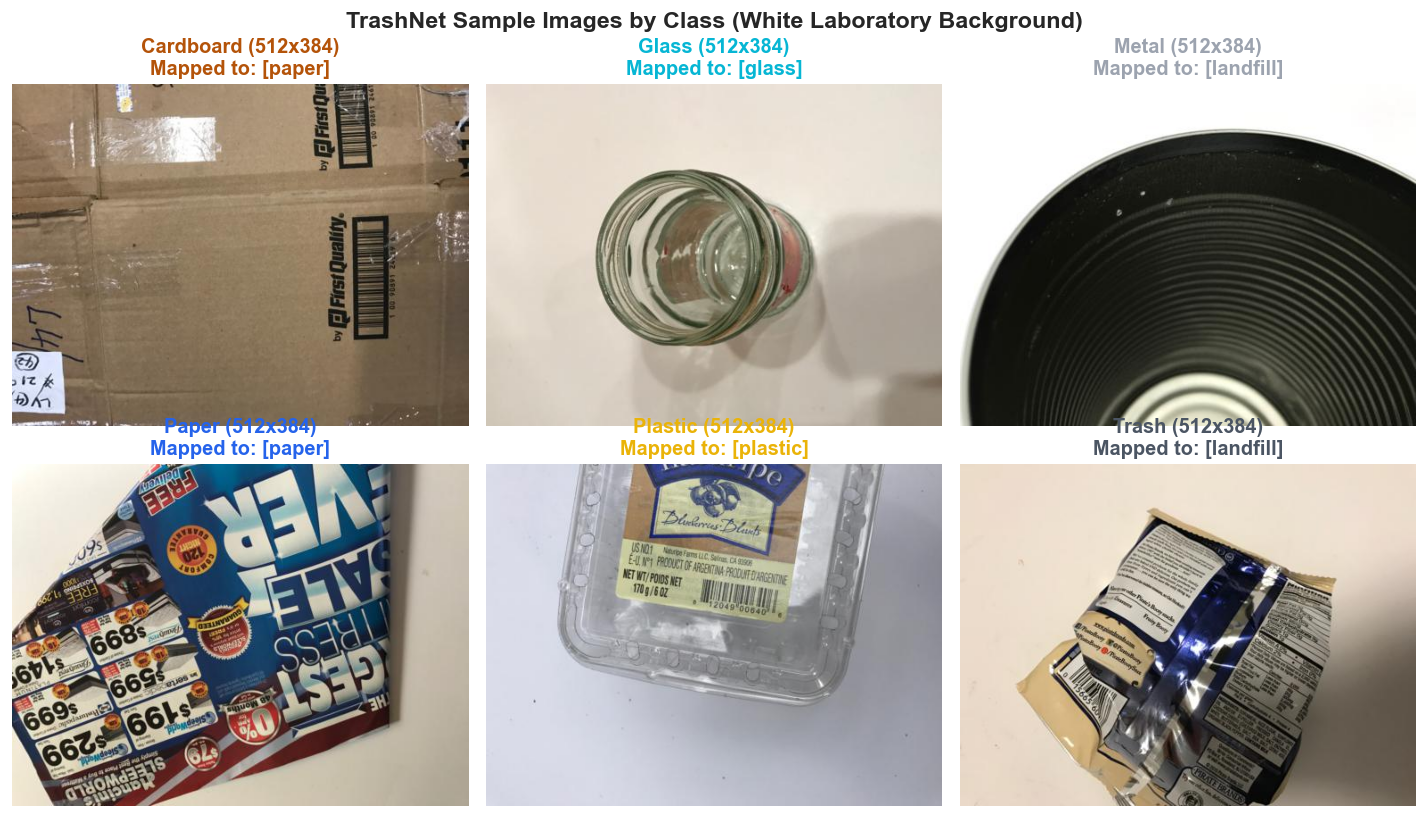

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()

raw_classes = sorted(df["raw_class"].unique())

for idx, cls in enumerate(raw_classes):
    sample_row = df[df["raw_class"] == cls].iloc[10]
    img = Image.open(sample_row["path"])

    ax = axes[idx]
    ax.imshow(img)
    ax.set_title(
        f"{cls.capitalize()} ({sample_row['width']}x{sample_row['height']})\nMapped to: [{sample_row['sortify_class']}]",
        fontweight="bold",
        color=RAW_COLORS.get(cls, "#333333"),
    )
    ax.axis("off")

plt.suptitle(
    "TrashNet Sample Images by Class (White Laboratory Background)",
    fontsize=14,
    fontweight="bold",
    y=0.98,
)
plt.tight_layout()
plt.show()

## 7. Documented Data Biases & Domain Gaps
Comparing TrashNet against Sortify's target real-world UC Berkeley campus deployment highlights critical domain gaps:

1. **Severe Background Bias (The White Background Trap):**
   - *Observation:* 100% of TrashNet images were captured on uniform white poster board under controlled indoor lighting.
   - *Campus Reality:* Real waste items are scanned over stainless steel receptacles, cafeteria tables, outdoor concrete, or held in users' hands with complex background clutter.
   - *Impact:* Models trained solely on TrashNet risk relying on background brightness or shadow cues rather than object geometry.

2. **Class Imbalance & Complete Compost Absence:**
   - *Observation:* `compost` has **0 samples** in TrashNet. Furthermore, `paper` (cardboard + paper = 997 samples) outnumbers `trash` (137 samples) by over **7.2x**.
   - *Impact:* A naive classifier will achieve high nominal accuracy while failing completely on food waste and organics.

3. **Item Deformation & Soiling Gap:**
   - *Observation:* TrashNet items are largely intact, clean, and uncrushed (e.g. pristine plastic bottles, clean paper sheets).
   - *Campus Reality:* Items in recycling bins are crushed aluminum cans, crumpled greasy napkins, shredded cardboard, or stained coffee cups.

4. **Aspect Ratio & Scale Bias:**
   - *Observation:* 100% of images are landscape `(512×384)`.
   - *Campus Reality:* Mobile phone scans taken via React Native Expo are held vertically in portrait orientation `(3:4 or 9:16)`. Direct squishing to `224×224` distorts tall rectangular objects.


## 8. Concrete Augmentation Recommendations for PyTorch Pipeline
Based on our findings, we formulate concrete transform pipelines for Kathleen's Week 3 `ml/scripts/dataset.py` DataLoaders:

| Transformation | Recommended Parameters | Justification / Domain Gap Mitigated |
| :--- | :--- | :--- |
| **`RandomResizedCrop`** | `size=224, scale=(0.7, 1.0)` | Introduces scale invariance and handles varied camera distances (8–18 inches). |
| **`RandomHorizontalFlip`** | `p=0.5` | Reflects bilateral symmetry of bottles, cans, and containers. |
| **`RandomRotation`** | `degrees=15` | Simulates handheld mobile phone tilt and non-orthogonal scanning angles. |
| **`ColorJitter`** | `brightness=0.25, contrast=0.25, saturation=0.2` | Counteracts the white background bias; simulates outdoor sun, indoor fluorescents, and shadows. |
| **`ImageNet Normalize`** | `mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]` | Matches pretrained ResNet-18 backbone feature distribution. |
| **Class Weighting / Loss Adjustment** | `weight=[w_paper, w_plastic, w_glass, w_compost, w_landfill]` | Counteracts the 7.2x imbalance between paper and trash. |


## 9. Comprehensive EDA Summary Figure Export
Assemble a 4-panel, high-resolution (300 DPI) infographic figure illustrating the key EDA findings and export to `docs/ml/eda_summary.png`.


In [7]:
fig = plt.figure(figsize=(16, 11), dpi=300)
gs = fig.add_gridspec(2, 2, hspace=0.32, wspace=0.25)

# --- Subplot 1: Raw TrashNet Class Counts ---
ax1 = fig.add_subplot(gs[0, 0])
raw_order = raw_counts.index.tolist()
bars1 = ax1.bar(
    raw_order,
    raw_counts.values,
    color=[RAW_COLORS.get(c, "#6B7280") for c in raw_order],
    edgecolor="#1F2937",
    linewidth=1.2,
)
ax1.set_title(
    "1. Raw TrashNet Class Distribution (2,527 Total Images)", fontweight="bold", pad=10
)
ax1.set_xlabel("Original Dataset Class", fontweight="bold")
ax1.set_ylabel("Image Count", fontweight="bold")
ax1.set_ylim(0, max(raw_counts.values) * 1.15)
for bar in bars1:
    yval = bar.get_height()
    pct = yval / len(df) * 100
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 12,
        f"{yval:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )

# --- Subplot 2: Sortify 5-Class Target Distribution ---
ax2 = fig.add_subplot(gs[0, 1])
classes_5 = ["paper", "plastic", "glass", "landfill", "compost"]
counts_5 = [sortify_counts.get(c, 0) for c in classes_5]
bars2 = ax2.bar(
    classes_5,
    counts_5,
    color=[SORTIFY_COLORS.get(c, "#6B7280") for c in classes_5],
    edgecolor="#1F2937",
    linewidth=1.2,
)
ax2.set_title(
    "2. Sortify 5-Class Target Mapping (Notice: 0 Compost)", fontweight="bold", pad=10
)
ax2.set_xlabel("Target Waste Category", fontweight="bold")
ax2.set_ylabel("Image Count", fontweight="bold")
ax2.set_ylim(0, max(counts_5) * 1.15)
for bar in bars2:
    yval = bar.get_height()
    pct = (yval / len(df) * 100) if len(df) > 0 else 0
    label = f"{yval:,}\n({pct:.1f}%)" if yval > 0 else "0\n(GAP!)"
    color = "#DC2626" if yval == 0 else "#111827"
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 12,
        label,
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color=color,
    )

# --- Subplot 3: Aspect Ratio & Resolution Geometry ---
ax3 = fig.add_subplot(gs[1, 0])
aspect_counts = df["aspect_ratio"].value_counts().head(5)
ar_labels = [f"4:3 Landscape ({ar})" for ar in aspect_counts.index]
ax3.pie(
    aspect_counts.values,
    labels=ar_labels,
    autopct="%1.1f%%",
    startangle=140,
    colors=["#3B82F6", "#60A5FA", "#93C5FD"],
    textprops={"fontweight": "bold", "fontsize": 10},
)
ax3.set_title(
    "3. Dataset Geometry (Uniform 512x384 Landscape)\nvs. Target Mobile Portrait Feed (3:4 or 9:16)",
    fontweight="bold",
    pad=10,
)

# --- Subplot 4: Domain Bias Breakdown & Augmentation Summary ---
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis("off")
findings_text = (
    "4. Key Insights & Augmentation Strategy\n\n"
    "• Domain Gap 1: Uniform White Backgrounds\n"
    "   - Real campus scans have stainless steel, wood, and concrete backgrounds.\n"
    "   - Recommendation: ColorJitter(brightness=0.25, contrast=0.25).\n\n"
    "• Domain Gap 2: Critical Compost Absence\n"
    "   - TrashNet contains 0 compost samples. Paper comprises 39.5% of dataset.\n"
    "   - Recommendation: Targeted campus photo collection + Class weighting.\n\n"
    "• Domain Gap 3: Mobile Orientation & Scale Variance\n"
    "   - Smartphone users scan at variable distances and handheld angles.\n"
    "   - Recommendation: RandomResizedCrop(224, scale=(0.7, 1.0))\n"
    "     and RandomRotation(degrees=15)."
)
ax4.text(
    0.04,
    0.95,
    findings_text,
    transform=ax4.transAxes,
    fontsize=10.5,
    verticalalignment="top",
    fontfamily="sans-serif",
    bbox={
        "boxstyle": "round,pad=1.0",
        "facecolor": "#F8FAFC",
        "edgecolor": "#CBD5E1",
        "linewidth": 1.5,
    },
)

fig.suptitle(
    "Sortify — Exploratory Data Analysis & Augmentation Blueprint",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)

# Save figure to docs/ml/eda_summary.png
output_file = DOCS_DIR / "eda_summary.png"
fig.savefig(output_file, bbox_inches="tight", dpi=300)
plt.close(fig)

print(f"High-resolution summary successfully exported to: {output_file}")
print(f"File size: {round(output_file.stat().st_size / 1024, 1)} KB")

High-resolution summary successfully exported to: C:\Users\caden\Documents\Open Project\Sortify\Sortify\docs\ml\eda_summary.png
File size: 556.5 KB
